# ML SVM - Support Vector Machine pour Trading

**Objectif**: Utiliser les machines a vecteurs de support (SVM) pour la classification de direction des prix.

## Strategie

1. **Hyperplan optimal**: Trouver la frontiere de decision maximisant la marge
2. **Kernel RBF**: Capturer les relations non-lineaires dans les donnees
3. **Standardisation**: Features normalisees pour performance optimale
4. **Probabilites**: Platt scaling pour estimer la confiance
5. **Margin analysis**: Utiliser la distance a l'hyperplan comme confiance

## Prerequis

- scikit-learn: `pip install scikit-learn`
- Comprehension des hyperplans et kernels

## Duree estimee: 50 minutes

In [1]:
# Initialisation QuantBook
from AlgorithmImports import *

qb = QuantBook()

# Periode d'analyse
qb.SetStartDate(2020, 1, 1)
qb.SetEndDate(2024, 12, 31)

print(f"Periode: {qb.StartDate} a {qb.EndDate}")

Periode: 2020-01-01 00:00:00 a 2024-12-31 23:59:59.999999


## 1. Chargement des Donnees

In [2]:
# Ajouter les ETFs
tickers = ['SPY', 'QQQ', 'IWM', 'IWM', 'USO']
symbols = {}

for ticker in tickers:
    symbols[ticker] = qb.AddEquity(ticker, Resolution.DAILY).Symbol

# Recuperer les donnees
history = qb.History(list(symbols.values()), 365*5, Resolution.Daily)

closes = history['close'].unstack(level=0)
volumes = history['volume'].unstack(level=0)
highs = history['high'].unstack(level=0)
lows = history['low'].unstack(level=0)

print(f"Donnees: {closes.shape[0]} jours, {closes.shape[1]} actifs")
closes.head()

Donnees: 1825 jours, 4 actifs


symbol,IWM,QQQ,SPY,USO
time,,,,
2012-09-28 16:00:00,73.973411,62.817682,121.773920,273.04
2012-10-01 16:00:00,74.203857,62.716925,122.036199,274.00
2012-10-02 16:00:00,74.345671,62.900120,122.256176,272.16
2012-10-03 16:00:00,74.124087,63.284830,122.738432,260.88
2012-10-04 16:00:00,74.629298,63.522984,123.753708,271.60


## 2. Feature Engineering pour SVM

In [3]:
def calculate_svm_features(closes, volumes, highs, lows):
    """Calcule les features optimisees pour SVM."""
    features = pd.DataFrame()
    
    for ticker in closes.columns:
        close = closes[ticker]
        volume = volumes[ticker]
        high = highs[ticker]
        low = lows[ticker]
        
        returns = close.pct_change()
        
        # Moving averages
        sma_5 = close.rolling(5).mean()
        sma_20 = close.rolling(20).mean()
        sma_50 = close.rolling(50).mean()
        
        # RSI (normalise 0-1)
        delta = close.diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rs = gain / loss
        rsi = (100 - (100 / (1 + rs))) / 100  # Normalise
        
        # MACD
        ema_12 = close.ewm(span=12).mean()
        ema_26 = close.ewm(span=26).mean()
        macd = ema_12 - ema_26
        macd_signal = macd.ewm(span=9).mean()
        
        # Bollinger Band position (-1 a 1)
        bb_middle = close.rolling(20).mean()
        bb_std = close.rolling(20).std()
        bb_position = (close - bb_middle) / (2 * bb_std)
        bb_position = bb_position.clip(-2, 2) / 2  # Normalise
        
        # Momentum
        mom_5 = close / close.shift(5) - 1
        mom_10 = close / close.shift(10) - 1
        mom_20 = close / close.shift(20) - 1
        
        # Volatility
        volatility = returns.rolling(20).std()
        
        # Volume ratio (normalise)
        volume_sma = volume.rolling(20).mean()
        volume_ratio = volume / (volume_sma + 0.0001)
        volume_ratio = volume_ratio.clip(0, 5) / 5  # Normalise
        
        # Price ratios
        price_sma5 = close / sma_5 - 1
        price_sma20 = close / sma_20 - 1
        price_sma50 = close / sma_50 - 1
        
        # ADX (trend strength)
        high_diff = high.diff()
        low_diff = -low.diff()
        
        plus_dm = high_diff.where((high_diff > low_diff) & (high_diff > 0), 0)
        minus_dm = low_diff.where((low_diff > high_diff) & (low_diff > 0), 0)
        
        high_low = high - low
        high_close = abs(high - close.shift())
        low_close = abs(low - close.shift())
        tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        atr = tr.rolling(14).mean()
        
        plus_di = 100 * (plus_dm.rolling(14).mean() / (atr + 0.0001))
        minus_di = 100 * (minus_dm.rolling(14).mean() / (atr + 0.0001))
        
        dx = 100 * abs(plus_di - minus_di) / (plus_di + minus_di + 0.0001)
        adx = dx.rolling(14).mean() / 100  # Normalise
        
        # Combiner
        ticker_features = pd.DataFrame({
            f'{ticker}_rsi': rsi,
            f'{ticker}_bb_position': bb_position,
            f'{ticker}_macd_norm': macd / (close + 0.0001),
            f'{ticker}_macd_hist_norm': (macd - macd_signal) / (close + 0.0001),
            f'{ticker}_mom_5': mom_5,
            f'{ticker}_mom_10': mom_10,
            f'{ticker}_mom_20': mom_20,
            f'{ticker}_volatility': volatility,
            f'{ticker}_volume_ratio': volume_ratio,
            f'{ticker}_price_sma5': price_sma5,
            f'{ticker}_price_sma20': price_sma20,
            f'{ticker}_price_sma50': price_sma50,
            f'{ticker}_adx': adx.fillna(0.25),
        })
        
        features = pd.concat([features, ticker_features], axis=1)
    
    return features.fillna(0)

# Calculer les features
features = calculate_svm_features(closes, volumes, highs, lows)

print(f"Features shape: {features.shape}")
print(f"\nFeatures par actif: {features.shape[1] // len(tickers)}")

Features shape: (1825, 52)

Features par actif: 10


## 3. Standardisation des Donnees

In [4]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Preparer les donnees pour SPY
spy_features = features[[c for c in features.columns if 'SPY' in c]]
spy_returns = closes['SPY'].pct_change()

# Target: direction
target = (spy_returns.shift(-1) > 0).astype(int)

# Dataset
data = spy_features.copy()
data['target'] = target
data = data.dropna()

X = data.drop('target', axis=1)
y = data['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# CRITICAL: Standardiser pour SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")
print(f"\nMoyenne apres standardisation: {X_train_scaled.mean(axis=0)[0]:.4f}")
print(f"Std apres standardisation: {X_train_scaled.std(axis=0)[0]:.4f}")

Train: 1460 samples
Test: 365 samples

Moyenne apres standardisation: 0.0000
Std apres standardisation: 1.0000


## 4. Entrainement SVM avec Kernel RBF

In [5]:
# Entrainer SVM
svm_model = SVC(
    C=1.0,
    kernel='rbf',
    gamma='scale',
    probability=True,  # Pour obtenir les probabilites
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# Previsions
y_pred = svm_model.predict(X_test_scaled)
y_proba = svm_model.predict_proba(X_test_scaled)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")
print(f"\nRapport de classification:")
print(classification_report(y_test, y_pred, target_names=['Baisse', 'Hausse']))

Accuracy: 51.78%

Rapport de classification:
              precision    recall  f1-score   support

      Baisse       0.41      0.21      0.28       161
      Hausse       0.55      0.76      0.64       204

    accuracy                           0.52       365
   macro avg       0.48      0.49      0.46       365
weighted avg       0.49      0.52      0.48       365



## 5. Analyse des Marges

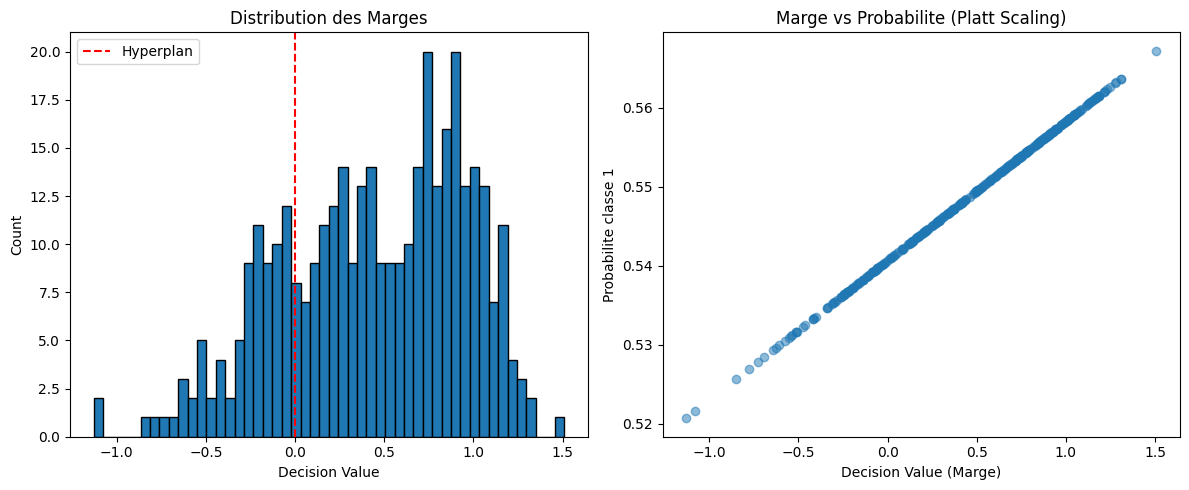

Marge moyenne: 0.4402
Marge std: 0.5066


In [6]:
import matplotlib.pyplot as plt

# Distance a l'hyperplan (decision function)
decision_values = svm_model.decision_function(X_test_scaled)

# Visualiser la distribution des marges
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(decision_values, bins=50, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Hyperplan')
plt.xlabel('Decision Value')
plt.ylabel('Count')
plt.title('Distribution des Marges')
plt.legend()

plt.subplot(1, 2, 2)
# Marge vs probabilite
proba_class1 = y_proba[:, 1]
plt.scatter(decision_values, proba_class1, alpha=0.5)
plt.xlabel('Decision Value (Marge)')
plt.ylabel('Probabilite classe 1')
plt.title('Marge vs Probabilite (Platt Scaling)')

plt.tight_layout()
plt.show()

print(f"Marge moyenne: {decision_values.mean():.4f}")
print(f"Marge std: {decision_values.std():.4f}")

## 6. Comparaison des Kernels

Kernel linear: 55.89%
Kernel poly: 53.97%
Kernel rbf: 51.78%


Kernel sigmoid: 45.75%


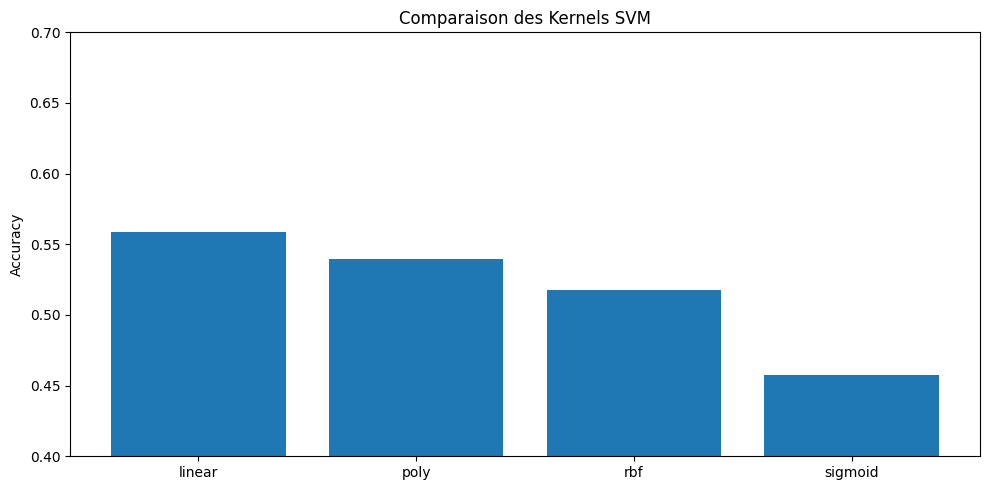

In [7]:
# Comparer differents kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for kernel in kernels:
    model = SVC(C=1.0, kernel=kernel, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    results[kernel] = acc
    print(f"Kernel {kernel}: {acc:.2%}")

# Visualiser
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values())
plt.ylabel('Accuracy')
plt.title('Comparaison des Kernels SVM')
plt.ylim(0.4, 0.7)
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning (C et Gamma)

In [8]:
from sklearn.model_selection import GridSearchCV

# Grille de parametres
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf']
}

# Recherche
svm_grid = SVC(random_state=42)

grid_search = GridSearchCV(
    svm_grid, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nMeilleurs parametres: {grid_search.best_params_}")
print(f"Meilleur score: {grid_search.best_score_:.2%}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits



Meilleurs parametres: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Meilleur score: 54.93%


## 8. Walk-Forward Validation

In [9]:
def walk_forward_svm(X, y, train_size=252, test_size=63):
    """Validation walk-forward pour SVM."""
    
    predictions = []
    actuals = []
    margins = []
    
    for start in range(0, len(X) - train_size - test_size, test_size):
        train_end = start + train_size
        test_end = train_end + test_size
        
        # Split
        X_train_wf = X.iloc[start:train_end]
        y_train_wf = y.iloc[start:train_end]
        X_test_wf = X.iloc[train_end:test_end]
        y_test_wf = y.iloc[train_end:test_end]
        
        # Standardiser
        scaler_wf = StandardScaler()
        X_train_scaled = scaler_wf.fit_transform(X_train_wf)
        X_test_scaled = scaler_wf.transform(X_test_wf)
        
        # Entrainer
        model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
        model.fit(X_train_scaled, y_train_wf)
        
        # Prevoir
        pred = model.predict(X_test_scaled)
        margin = model.decision_function(X_test_scaled)
        
        predictions.extend(pred)
        actuals.extend(y_test_wf.values)
        margins.extend(margin)
    
    return np.array(predictions), np.array(actuals), np.array(margins)

# Executer
wf_pred, wf_actual, wf_margins = walk_forward_svm(X, y)

# Resultats
wf_accuracy = (wf_pred == wf_actual).mean()

# Accuracy par niveau de confiance
high_conf_mask = np.abs(wf_margins) > 0.5
high_conf_accuracy = (wf_pred[high_conf_mask] == wf_actual[high_conf_mask]).mean()

print(f"Walk-Forward Accuracy: {wf_accuracy:.2%}")
print(f"High Confidence Accuracy (|margin| > 0.5): {high_conf_accuracy:.2%}")
print(f"High Confidence Samples: {high_conf_mask.sum()}/{len(wf_margins)}")

Walk-Forward Accuracy: 53.37%
High Confidence Accuracy (|margin| > 0.5): 53.61%
High Confidence Samples: 927/1512


## 9. Backtest avec Confidence Weighting

In [10]:
def backtest_svm_strategy(closes, features, train_period=252, rebalance_freq=5):
    """Backtest strategie SVM avec position sizing base sur la marge."""
    
    portfolio_value = 100000
    positions = {}
    
    for i in range(train_period, len(closes) - 1, rebalance_freq):
        current_date = closes.index[i]
        
        # Entrainer
        train_features = features.iloc[i-train_period:i]
        spy_returns = closes['SPY'].pct_change().iloc[i-train_period:i]
        target = (spy_returns.shift(-1) > 0).astype(int)
        
        train_data = train_features.copy()
        train_data['target'] = target
        train_data = train_data.dropna()
        
        if len(train_data) < 50:
            continue
        
        X_train = train_data.drop('target', axis=1)
        y_train = train_data['target']
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        
        model = SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
        model.fit(X_train_scaled, y_train)
        
        # Prevoir en utilisant TOUTES les features (pas par ticker)
        if i + 1 >= len(features):
            continue
        
        latest = features.iloc[i:i+1].values
        latest_scaled = scaler.transform(latest)
        
        proba = model.predict_proba(latest_scaled)[0]
        margin = model.decision_function(latest_scaled)[0]
        spy_signal = proba[1]
        
        # Liquider
        for t, qty in positions.items():
            portfolio_value += qty * closes[t].iloc[i]
        positions = {}
        
        # Nouvelles positions avec confidence weighting
        if spy_signal > 0.55:
            confidence = min(abs(margin) / 2, 1)
            position_size = portfolio_value * 0.40 * (0.5 + 0.5 * confidence)
            
            recent_rets = closes.iloc[i-20:i].pct_change().sum()
            top_tickers = recent_rets.nlargest(2).index.tolist()
            
            count = 0
            for ticker in top_tickers:
                if ticker in closes.columns and count < 2:
                    ps = position_size / 2
                    price = closes[ticker].iloc[i]
                    positions[ticker] = ps / price
                    portfolio_value -= ps
                    count += 1
    
    # Valeur finale
    final_value = portfolio_value
    for t, qty in positions.items():
        final_value += qty * closes[t].iloc[-1]
    
    return {
        'initial': 100000,
        'final': final_value,
        'return': (final_value - 100000) / 100000
    }

# Executer
results = backtest_svm_strategy(closes, features)

print("")
print("Backtest Results:")
initial_str = f"Valeur initiale: ${results['initial']:,.2f}"
final_str = f"Valeur finale: ${results['final']:,.2f}"
ret_str = f"Rendement total: {results['return']:.2%}"
print(initial_str)
print(final_str)
print(ret_str)


/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

...

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho


Backtest Results:
Valeur initiale: $100,000.00
Valeur finale: $105,765.96
Rendement total: 5.77%


/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

## 10. Avantages et Limites de SVM

### Avantages
- **Efficace en haute dimension**: Performe bien avec beaucoup de features
- **Kernel trick**: Capture les relations non-lineaires
- **Marge maximale**: Robuste aux outliers
- **Interpretabilite partielle**: Decision values indiquent la confiance

### Limites
- **Sensibilite a l'echelle**: Standardisation obligatoire
- **Choix du kernel**: Pas toujours evident
- **Lenteur**: O(n^2) a O(n^3) pour l'entrainement
- **Parametres C et gamma**: Sensibles, necessitent tuning